## Basic creation of a ScanData object

**Note:**

geecs_data_utils makes use of GEECSPathConfig() which is loaded in the background. This looks for a specific config file which has details about the users desired defaults. If this config doesn't exist, some basic attributes need to be set.

In [1]:
from geecs_data_utils import ScanData

# if no config file exists, set base path to experiment data as below.
# Assumption is that data is stored like <base_path>/<experiment name>
# ScanPaths.paths_config.base_path = Path('Z:/data')

# Create ScanData object directly referencing year, month, data, scan number and experiment
sd = ScanData.from_date(year=2026, month=4, day=23, number=4, experiment="Undulator")

# inspect the head of the data_frame
sd.data_frame.head()

,Elapsed Time,Bin #,scan,U_BCaveHallProbe Rawfield,U_BCaveHallProbe Field,U_BCaveMagSpecPS Rawfield,U_BCaveMagSpecPS Current_Limit.Ch1,U_BCaveMagSpecPS Field,U_VacuumGauge AI_mean.Channel 0 Alias:B-cave,U_VacuumGauge AI_mean.Channel 1 Alias:A-Cave,...,UC_Amp2_IR_input_y_45_peak_location,UC_Amp2_IR_input_y_45_rms,UC_Amp2_IR_input_y_CoM,UC_Amp2_IR_input_y_fwhm,UC_Amp2_IR_input_y_peak_location,UC_Amp2_IR_input_y_rms,U_FROG_Grenouille-Temporal_frog_error,U_FROG_Grenouille-Temporal_frog_iterations,U_FROG_Grenouille-Temporal_spectral_fwhm,U_FROG_Grenouille-Temporal_temporal_fwhm
0,27.0,1,4,829.78,0.0,NaN,100.0,NaN,2.870980,0.997132,...,527.0,58.814646,262.531757,86.409765,249.0,39.781880,0.004604,418.0,17.428787,55.819939
1,28.0,1,4,829.77,0.0,NaN,100.0,NaN,3.599528,0.996994,...,528.0,58.740965,262.210258,86.612718,249.0,39.855766,0.005076,372.0,17.581402,52.960084
2,29.0,1,4,829.77,0.0,NaN,100.0,NaN,3.837198,0.997254,...,526.0,58.769332,261.943411,86.763508,249.0,39.962763,0.004898,349.0,17.259048,52.386664
3,30.0,1,4,829.77,0.0,NaN,100.0,NaN,4.034873,0.997259,...,528.0,58.207799,262.127242,86.137470,249.0,39.365269,0.004854,405.0,16.962730,52.456082
4,31.0,1,4,829.77,0.0,NaN,100.0,NaN,3.845384,0.996964,...,526.0,58.062736,262.400835,86.057570,249.0,39.349603,0.008544,405.0,19.650752,41.255212


Note, in the above, the expected path of the saved device data (non scalar data) is directly appended to the data_frame. These are just the expected paths based on configuration etc. 

## Column discovery (`geecs_data_utils.data`)

Shared matching helpers work on any DataFrame (same semantics as `ScanData.find_cols` / `resolve_col`, which delegate here).
Each code cell below creates **`sd`** if it is not already defined, so this subsection runs without the **`ScanData`** introduction.


In [3]:
from geecs_data_utils import ScanData
from geecs_data_utils.data import find_cols, resolve_col

sd = ScanData.from_date(year=2026, month=4, day=23, number=4, experiment="Undulator")

result = find_cols(sd.data_frame, "ict charge")
print(f"find_cols result: {result}")

result = resolve_col(sd.data_frame, "ict charge")
print(f"resolve_col result: {result}")

find_cols result: ['U_BCaveICT Python Results.ChA Alias:U_BCaveICT Charge pC', 'U_BCaveICT Python Results.ChB Alias:U_UndulatorExit_ICT Charge pC']
resolve_col result: U_BCaveICT Python Results.ChA Alias:U_BCaveICT Charge pC


The above functionality is also wrapped in the `ScanData` functionality.

In [5]:
result = sd.find_cols("ict charge")
print(f"ScanData.find_cols result: {result}")

result = sd.resolve_col("ict charge")
print(f"ScanData.resolve_col result: {result}")

ScanData.find_cols result: ['U_BCaveICT Python Results.ChA Alias:U_BCaveICT Charge pC', 'U_BCaveICT Python Results.ChB Alias:U_UndulatorExit_ICT Charge pC']
ScanData.resolve_col result: U_BCaveICT Python Results.ChA Alias:U_BCaveICT Charge pC


## Working with binned data

binned_scalars is a property of the ScanData that can be accessed or used for plotting. There are number of attributes that are user defineable, like the aggretate type (i.e. 'agg') which can be mean or median. Also, there are a number of optitions for the error bar type. Default is to use mean and the inter quartile range error bars (same as GEECS Plotter default). See API for more details

There is also a basic plot utility for visualizing binned data in geecs_data_utils.plotting_utils
The plotting cells load **`sd`** (and **`charge_col`** where needed) if missing, using the same scan defaults as the **`ScanData`** example.


/Users/kjensen/projects/GEECS-Workspace/GEECS-Plugins/GEECS-Data-Utils/geecs_data_utils/scan_data.py:699: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[("count", "center")] = counts


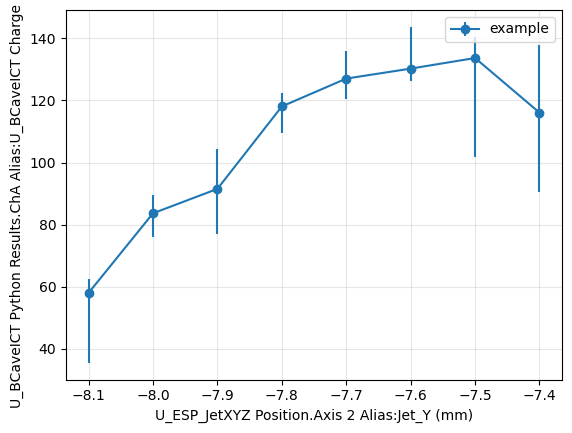

In [6]:
from geecs_data_utils import ScanData
from geecs_data_utils.plotting_utils import plot_binned
import matplotlib.pyplot as plt

sd = ScanData.from_date(year=2026, month=4, day=23, number=4, experiment="Undulator")

sd.set_binning_config(bin_col="Bin #")

binned = sd.binned_scalars
charge_col = sd.find_cols("charge")[3]

plot_binned(
    binned,
    x_col="U_ESP_JetXYZ Position.Axis 2 Alias:Jet_Y (mm)",
    y_col=charge_col,
    label="example",
)

plt.show()

Reconfigure the binned data. Use 'charge' as the x axis with defined bin_width of 20. Change to mean and standard deviation

/Users/kjensen/projects/GEECS-Workspace/GEECS-Plugins/GEECS-Data-Utils/geecs_data_utils/scan_data.py:699: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[("count", "center")] = counts


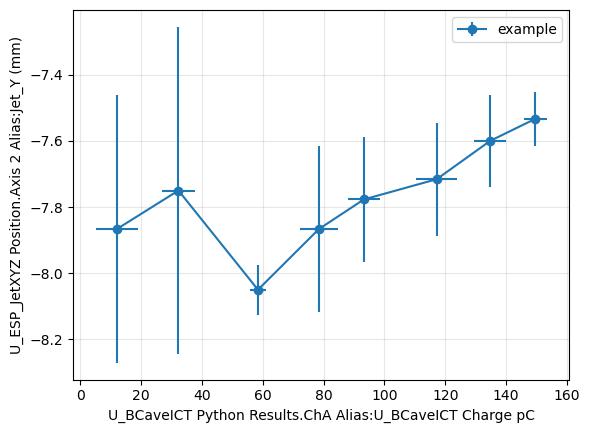

In [8]:
from geecs_data_utils.plotting_utils import plot_binned
import matplotlib.pyplot as plt

sd.set_binning_config(bin_col="Bin #")
charge_col = sd.find_cols("charge")[3]

sd.set_binning_config(
    bin_col=charge_col,
    agg="mean",
    err="std",
    min_count=1,
    dropna="any",
    bin_width=20,
)

bins1 = sd.binned_scalars

plot_binned(
    bins1,
    x_col=charge_col,
    y_col="U_ESP_JetXYZ Position.Axis 2 Alias:Jet_Y (mm)",
    label="example",
)
plt.show()

## Gather device data by shot number, verify existence

Create dataframe of shotnumber and files paths for devices restricted to shotnumbers where all devices are saved

In [9]:
# make list of tuples with <device> <file_tail>. Note, file names are typically:
# Scan<scan_number>DeviceName<shotnumber><extra><extenstion>. Here file_tail represents
# everything after <shotnumber>. For example, for magspec type device, could be ('magspec', 'interpSpec.txt')

sd = ScanData.from_date(year=2025, month=8, day=7, number=5, experiment="Undulator")

dev_list = [
    ("Z_Test_Scope", ".dat"),
    ("Z_Test_Scope_2", ".dat"),
    ("UC_ALineEBeam3", ".png"),
]
shots = sd.paths.get_common_shot_dataframe(dev_list)
shots.head(5)

ValueError: Folder /Users/kjensen/projects/GEECS-Workspace/data-mirror/Undulator/Y2025/08-Aug/25_0807/scans/Scan005 does not exist.

## Multi-scan table (`DatasetBuilder`)

Prefer **`DatasetBuilder.from_date_scan_numbers`** instead of hand-concatenating frames: it loads each scan, skips failures (see `load_report`), concatenates, and can apply shared row filters / outlier config / `dropna`.
Later cells in this subsection reload **`assembled`** and **`df`** if needed, so you can run **`DatasetBuilder`** plots without executing earlier parts of the notebook.


In [10]:
from geecs_data_utils.data import DatasetBuilder

assembled = DatasetBuilder.from_date_scan_numbers(
    year=2026,
    month=4,
    day=23,
    experiment="Undulator",
    numbers=range(1, 20),
    load_scalars=True,
    source="sfile",
    on_missing="skip",
    dropna=False,
)

df = assembled.frame
print(assembled.scan_info.get("total_scans"), "scans merged")
print(
    "Skipped:", assembled.load_report.skipped[:5], "..."
) if assembled.load_report else None
df.head()
df.shape

19 scans merged
Skipped: [] ...


(3205, 343)

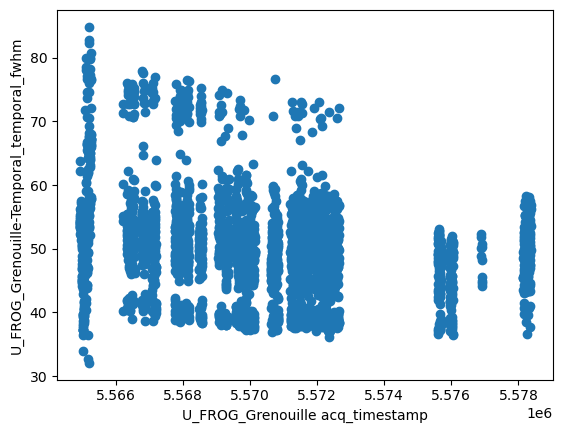

In [13]:
from geecs_data_utils.data import DatasetBuilder
import matplotlib.pyplot as plt

assembled = DatasetBuilder.from_date_scan_numbers(
    year=2026,
    month=4,
    day=23,
    experiment="Undulator",
    numbers=range(1, 20),
    load_scalars=True,
    source="sfile",
    on_missing="skip",
    dropna=False,
)

df = assembled.frame


plt.scatter(
    df["U_FROG_Grenouille acq_timestamp"] - 3.8542465e9,
    df["U_FROG_Grenouille-Temporal_temporal_fwhm"],
)
plt.xlabel("U_FROG_Grenouille acq_timestamp")
plt.ylabel("U_FROG_Grenouille-Temporal_temporal_fwhm")
plt.show()

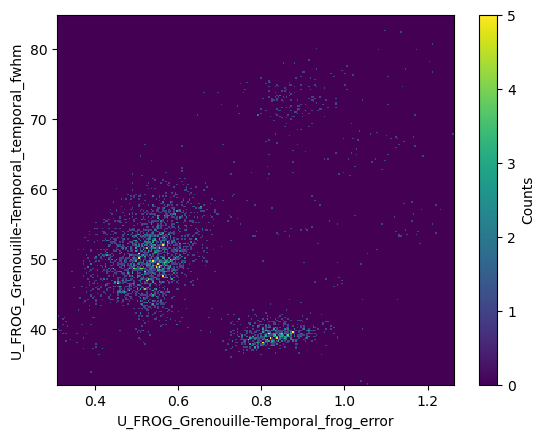

In [14]:
x_col = "U_FROG_Grenouille-Temporal_frog_error"
y_col = "U_FROG_Grenouille-Temporal_temporal_fwhm"

subset = df[[x_col, y_col]].dropna()

plt.hist2d(
    subset[x_col] * 100,
    subset[y_col],
    bins=250,
)

plt.xlabel(x_col)
plt.ylabel(y_col)
plt.colorbar(label="Counts")
plt.show()

In [15]:
from geecs_data_utils.data import find_cols

result = find_cols(df, "frog")
print(result)

cols = [c for c in df.columns if "frog" in c.lower()]
print(cols)
print(f"Same results: {sorted(result) == sorted(cols)}")

['U_FROG_Grenouille acq_timestamp', 'U_FROG_Grenouille-Temporal_frog_error', 'U_FROG_Grenouille-Temporal_frog_iterations', 'U_FROG_Grenouille-Temporal_image_peak_value', 'U_FROG_Grenouille-Temporal_image_total', 'U_FROG_Grenouille-Temporal_spectral_fwhm', 'U_FROG_Grenouille-Temporal_temporal_fwhm', 'U_FROG_Grenouille-Temporal_x_45_CoM', 'U_FROG_Grenouille-Temporal_x_45_fwhm', 'U_FROG_Grenouille-Temporal_x_45_peak_location', 'U_FROG_Grenouille-Temporal_x_45_rms', 'U_FROG_Grenouille-Temporal_x_CoM', 'U_FROG_Grenouille-Temporal_x_fwhm', 'U_FROG_Grenouille-Temporal_x_peak_location', 'U_FROG_Grenouille-Temporal_x_rms', 'U_FROG_Grenouille-Temporal_y_45_CoM', 'U_FROG_Grenouille-Temporal_y_45_fwhm', 'U_FROG_Grenouille-Temporal_y_45_peak_location', 'U_FROG_Grenouille-Temporal_y_45_rms', 'U_FROG_Grenouille-Temporal_y_CoM', 'U_FROG_Grenouille-Temporal_y_fwhm', 'U_FROG_Grenouille-Temporal_y_peak_location', 'U_FROG_Grenouille-Temporal_y_rms']
['U_FROG_Grenouille acq_timestamp', 'U_FROG_Grenouille-T

## Correlation ranking (`geecs_data_utils.analysis`)

Use **`CorrelationReport.from_dataframe`** instead of ad-hoc notebook functions. Row filters use **`RowFilterSpec`** tuples. **`exclude_terms`** trims the reported correlation series only.

Outliers: use **`apply_outlier_config`** + **`OutlierConfig`** from `geecs_data_utils.data` (e.g. `method="nan"` with `sigma=`) before correlating.
Each recipe reloads data from disk independently — run either correlation example on its own.


In [16]:
from geecs_data_utils.data import DatasetBuilder, OutlierConfig, apply_outlier_config
from geecs_data_utils.analysis import CorrelationReport

assembled = DatasetBuilder.from_date_scan_numbers(
    year=2026,
    month=4,
    day=14,
    experiment="Undulator",
    numbers=range(39, 47),
    load_scalars=True,
    source="sfile",
    on_missing="skip",
    dropna=False,
)

df_capped = apply_outlier_config(
    assembled.frame.copy(),
    OutlierConfig(method="nan", sigma=5),
)

param = "U_BCaveICT Python Results.ChA Alias:U_BCaveICT Charge pC"

report = CorrelationReport.from_dataframe(
    df_capped,
    target=param,
    exclude_terms=[
        "charge",
        "magspec",
        "magcam",
        "esp",
        "HP_daq",
        "1HzShifted",
        "HallProbe",
        "jetz",
        "probecamstage",
        "timestamp",
        "scan",
        "Bin #",
        "Elapsed time",
        "Shotnumber",
        "Aerotech",
    ],
    filters=[(param, ">", 2)],
    top_n=100,
)

corrs = report.correlations
df_filt = report.filtered_frame

print(corrs.head(5))

U_GhostWFS RadiusOfCurvature                   0.349633
U_GhostWFS Zernike5                            0.348684
U_GhostWFS Zernike6                           -0.345087
U_GhostWFS Zernike8                           -0.301035
U_FROG_Grenouille-Temporal_image_peak_value   -0.277811
Name: U_BCaveICT Python Results.ChA Alias:U_BCaveICT Charge pC, dtype: float64


You can also handle filtering and outliers directly during dataset building rather than in downstream function calls or during correlation analysis. Each of these calls utilize the same central functionality.

In [17]:
from geecs_data_utils.data import DatasetBuilder, OutlierConfig
from geecs_data_utils.analysis import CorrelationReport

param = "U_BCaveICT Python Results.ChA Alias:U_BCaveICT Charge pC"

assembled = DatasetBuilder.from_date_scan_numbers(
    year=2026,
    month=4,
    day=14,
    experiment="Undulator",
    numbers=range(39, 47),
    filters=[(param, ">", 2)],
    outlier_config=OutlierConfig(method="nan", sigma=5),
    load_scalars=True,
    source="sfile",
    on_missing="skip",
    dropna=False,
)

report = CorrelationReport.from_dataframe(
    assembled.frame,
    target=param,
    exclude_terms=[
        "charge",
        "magspec",
        "magcam",
        "esp",
        "HP_daq",
        "1HzShifted",
        "HallProbe",
        "jetz",
        "probecamstage",
        "timestamp",
        "scan",
        "Bin #",
        "Elapsed time",
        "Shotnumber",
        "Aerotech",
    ],
    top_n=100,
)

corrs = report.correlations
df_filt = report.filtered_frame

print(corrs.head(5))

U_GhostWFS RadiusOfCurvature                   0.349633
U_GhostWFS Zernike5                            0.348684
U_GhostWFS Zernike6                           -0.345087
U_GhostWFS Zernike8                           -0.301035
U_FROG_Grenouille-Temporal_image_peak_value   -0.277811
Name: U_BCaveICT Python Results.ChA Alias:U_BCaveICT Charge pC, dtype: float64


### Modeling with sklearn (notebook-first)

This section is **self-contained**: it reloads the same scan merge and preprocessing used in **`basic_usage.ipynb`** (multi-scan table, ±5σ outliers → NaN on numeric columns, ICT charge target, threshold row filter) using **`DatasetBuilder`**, **`OutlierConfig`** / **`apply_outlier_config`**, **`CorrelationReport`**, and **`BeamPredictionDatasetBuilder`**.

Earlier notebook sections are optional here.

The following cells mirror **`basic_usage.ipynb`**: in-sample OLS, Monte Carlo train/test splits, PCA + reduced-rank regression, PLS, correlation preview, missing-value footprint, Optuna (linear / ridge / lasso), best-trial diagnostics, and sklearn **`Pipeline`** cross-validation.

For packaged fit/save/load workflows, see **`geecs_data_utils.modeling.ml`**.


#### Shared modeling table (`BeamPredictionDatasetBuilder`)

After correlation ranking, **`BeamPredictionDatasetBuilder.from_dataframe`** drops rows with NaN in **any** selected predictor or the target — the same effective definition as **`df_filt.dropna(subset=[target] + check_columns)`**, but kept in one place for all sklearn cells above.


In [2]:
from geecs_data_utils.data import DatasetBuilder, OutlierConfig, apply_outlier_config
from geecs_data_utils.analysis import CorrelationReport
from geecs_data_utils.modeling.ml import BeamPredictionDatasetBuilder

# Same defaults as basic_usage.ipynb: 2026-02-12, scans 22–26, ±5σ → NaN, ICT charge target
_LEGACY_DATE = dict(year=2026, month=4, day=14, experiment="Undulator")
_LEGACY_NUMBERS = range(39, 47)

assembled_model = DatasetBuilder.from_date_scan_numbers(
    **_LEGACY_DATE,
    numbers=_LEGACY_NUMBERS,
    append_paths=False,
    on_missing="skip",
    dropna=False,
)

df_raw_model = assembled_model.frame.copy()
df_capped_model = apply_outlier_config(
    df_raw_model,
    OutlierConfig(method="nan", sigma=5),
)

param = "U_BCaveICT Python Results.ChA Alias:U_BCaveICT Charge pC"

report_model = CorrelationReport.from_dataframe(
    df_capped_model,
    target=param,
    exclude_terms=[
        "charge",
        "magspec",
        "magcam",
        "esp",
        "HP_daq",
        "1HzShifted",
        "HallProbe",
        "jetz",
        "probecamstage",
        "timestamp",
        "scan",
        "Bin #",
        "Elapsed time",
        "Shotnumber",
        "Aerotech",
    ],
    filters=[(param, ">", 2)],
    top_n=100,
)

corrs = report_model.correlations
df_filt = report_model.filtered_frame

key_column = param
check_columns = corrs.index.tolist()

ml_ds = BeamPredictionDatasetBuilder.from_dataframe(
    df_filt,
    target_column=key_column,
    feature_columns=check_columns,
    dropna=True,
)

X_arr = ml_ds.frame[ml_ds.feature_columns].to_numpy(dtype=float)
y_arr = ml_ds.frame[ml_ds.target_column].to_numpy(dtype=float)

_lr = assembled_model.load_report
if _lr is not None:
    print(
        "Legacy-format merge: loaded scan numbers",
        list(_lr.numbers_loaded),
        f"({len(_lr.numbers_loaded)} ok, {len(_lr.skipped)} skipped)",
    )
print(f"Rows in correlation filtered_frame: {len(df_filt)}")
print(
    f"Modeling matrix after dropna on target + {len(check_columns)} features: {ml_ds.rows_final} rows"
)

Legacy-format merge: loaded scan numbers [39, 40, 41, 42, 43, 44, 45, 46] (8 ok, 0 skipped)
Rows in correlation filtered_frame: 7996
Modeling matrix after dropna on target + 100 features: 7167 rows


#### In-sample multivariate linear fit

Matches **`basic_usage.ipynb`**: scale all predictors, **`LinearRegression`**, variance explained (**`score`**), scatter actual vs predicted charge, 2D histogram.


Total variance explained by check parameters: 0.57


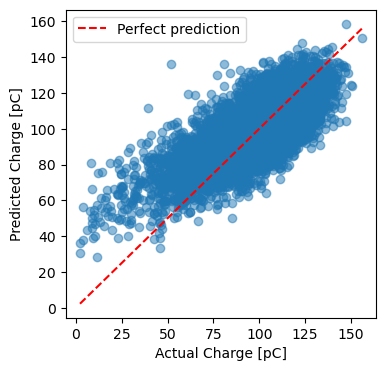

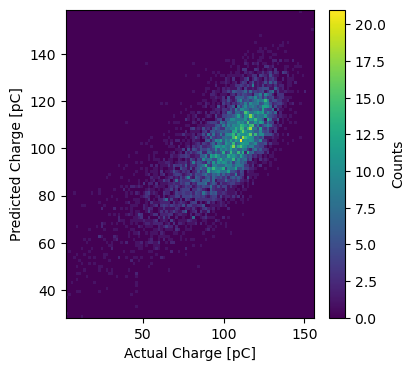

In [3]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_arr)

model = LinearRegression()
model.fit(X_scaled, y_arr)
r2 = model.score(X_scaled, y_arr)
y_pred = model.predict(X_scaled)

print(f"Total variance explained by check parameters: {r2:.2f}")

plt.figure(figsize=(4, 4))
plt.scatter(y_arr, y_pred, alpha=0.5)
plt.plot(
    [y_arr.min(), y_arr.max()],
    [y_arr.min(), y_arr.max()],
    "r--",
    label="Perfect prediction",
)
plt.xlabel("Actual Charge [pC]")
plt.ylabel("Predicted Charge [pC]")
plt.legend()
plt.show()

plt.figure(figsize=(4, 4))
plt.hist2d(y_arr, y_pred, bins=100)
plt.xlabel("Actual Charge [pC]")
plt.ylabel("Predicted Charge [pC]")
plt.colorbar(label="Counts")
plt.show()

#### Train / test splits (Monte Carlo loop)

Repeat **`train_test_split`** with **`random_state=i`** on **`X_scaled`** / **`y_arr`**, collect test **`R²`**, plot the **last** split (same layout as **`basic_usage.ipynb`**), then **`mean(vals)`** in the next cell.


Last split test R²: 0.537


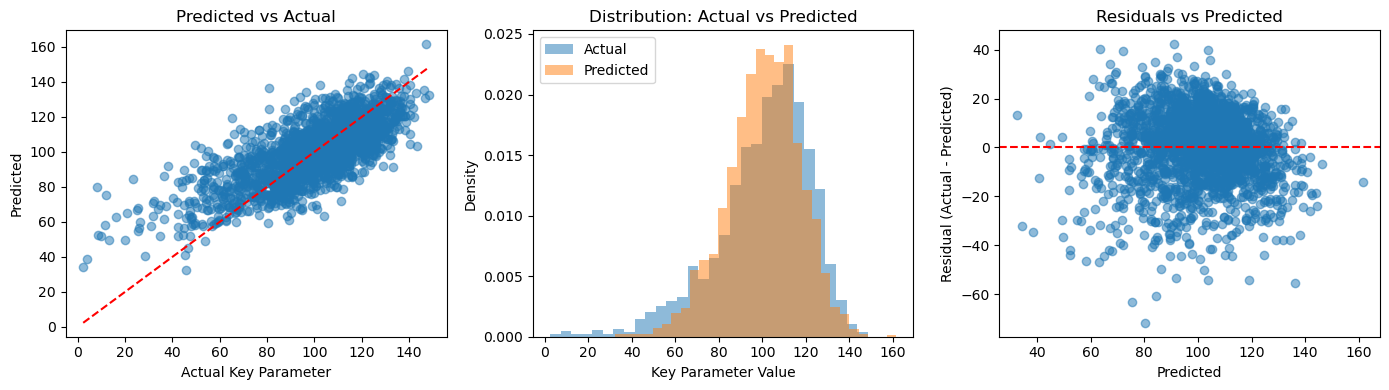

residual rms: 14.866
rms of original signal: 21.836
percentage of mean rms of residuals: 0.148
percentage of mean rms of signal: 0.217


In [4]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

vals = []

for i in range(1, 50):
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_arr, test_size=0.3, random_state=i
    )
    reg = LinearRegression()
    reg.fit(X_train, y_train)
    y_hat = reg.predict(X_test)
    r2_test = reg.score(X_test, y_test)
    vals.append(r2_test)

print(f"Last split test R²: {r2_test:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(y_test, y_hat, alpha=0.5)
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
)
axes[0].set_xlabel("Actual Key Parameter")
axes[0].set_ylabel("Predicted")
axes[0].set_title("Predicted vs Actual")

axes[1].hist(y_test, bins=30, alpha=0.5, label="Actual", density=True)
axes[1].hist(y_hat, bins=30, alpha=0.5, label="Predicted", density=True)
axes[1].set_xlabel("Key Parameter Value")
axes[1].set_ylabel("Density")
axes[1].set_title("Distribution: Actual vs Predicted")
axes[1].legend()

residuals = y_test - y_hat
axes[2].scatter(y_hat, residuals, alpha=0.5)
axes[2].axhline(0, color="r", linestyle="--")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Residual (Actual - Predicted)")
axes[2].set_title("Residuals vs Predicted")

plt.tight_layout()
plt.show()

print(f"residual rms: {np.std(residuals):.3f}")
print(f"rms of original signal: {np.std(y_test):.3f}")
print(f"percentage of mean rms of residuals: {np.std(residuals) / np.mean(y_test):.3f}")
print(f"percentage of mean rms of signal: {np.std(y_test) / np.mean(y_test):.3f}")

#### PCA on ranked predictors

Use **`df_filt[check_columns].dropna()`** and align **`y`** with **`df_filt.loc[X.index, key_column]`** — same indexing as **`basic_usage.ipynb`** (distinct from the `BeamPredictionDatasetBuilder` matrix so PCA row counts match the legacy notebook).


,PC,Explained Variance Ratio,Cumulative Variance
0,1,0.293567,0.293567
1,2,0.146312,0.439879
2,3,0.102073,0.541952
3,4,0.070965,0.612917
4,5,0.058849,0.671766
5,6,0.035918,0.707685
6,7,0.032739,0.740424
7,8,0.025615,0.766039
8,9,0.019270,0.785309
9,10,0.014326,0.799635


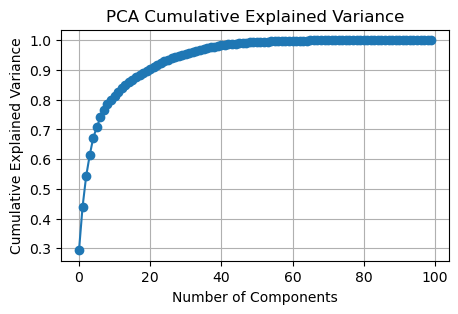

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df_filt[check_columns].copy()
X = X.dropna()

scaler_x = StandardScaler()
X_scaled_pca = scaler_x.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled_pca)

explained_variance = pca.explained_variance_ratio_
cum_variance = np.cumsum(explained_variance)

display(
    pd.DataFrame(
        {
            "PC": np.arange(1, len(explained_variance) + 1),
            "Explained Variance Ratio": explained_variance,
            "Cumulative Variance": cum_variance,
        }
    ).head(15)
)

plt.figure(figsize=(5, 3))
plt.plot(cum_variance, marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.grid(True)
plt.show()

In [7]:
import numpy as np

n_80 = int(np.argmax(cum_variance >= 0.80) + 1)
n_90 = int(np.argmax(cum_variance >= 0.90) + 1)
n_95 = int(np.argmax(cum_variance >= 0.95) + 1)

print("Components for 80% variance:", n_80)
print("Components for 90% variance:", n_90)
print("Components for 95% variance:", n_95)

Components for 80% variance: 11
Components for 90% variance: 21
Components for 95% variance: 30


In [8]:
from sklearn.linear_model import LinearRegression

y_pc = df_filt.loc[X.index, key_column]

N = n_95
X_reduced = X_pca[:, :N]

reg_pc = LinearRegression()
reg_pc.fit(X_reduced, y_pc)

r2_pca = reg_pc.score(X_reduced, y_pc)
print("R² using first", N, "PCs:", r2_pca)

R² using first 30 PCs: 0.44313390191055757


#### PLS regression

**`PLSRegression`** on **`X_scaled_pca`** with **`y_pls`** aligned to **`X.index`** (same rows as the PCA cell).


In [9]:
from sklearn.cross_decomposition import PLSRegression

y_pls = df_filt.loc[X.index, key_column].values

n_components = 10
pls = PLSRegression(n_components=n_components)
pls.fit(X_scaled_pca, y_pls)

r2_train = pls.score(X_scaled_pca, y_pls)
print(f"R² using {n_components} PLS components: {r2_train:.3f}")

R² using 10 PLS components: 0.497


#### Ranked correlations and per-column NaN footprint

Inspect **`corrs`** and quantify rows lost if each column were required individually.


In [10]:
import pandas as pd

corrs.head(40)

cols_ms = [key_column] + check_columns
rows_before = len(df_filt)

rows_lost = {}
for col in cols_ms:
    rows_after = df_filt.dropna(subset=[col]).shape[0]
    rows_lost[col] = rows_before - rows_after

rows_lost_series = pd.Series(rows_lost).sort_values(ascending=False)
rows_lost_series.head(20)

UC_ExpanderIn1_Pulsed_x_peak_location            226
UC_OAPin2_x_45_peak_location                     219
UC_Amp3_IR_input_x_peak_location                 165
UC_Amp3_IR_input_y_peak_location                 145
UC_ExpanderIn1_y_45_peak_location                 83
UC_OAPin2_y_peak_location                         82
U_FROG_Grenouille-Temporal_x_rms                  78
U_FROG_Grenouille-Temporal_x_CoM                  78
U_FROG_Grenouille-Temporal_image_peak_value       77
U_FROG_Grenouille-Temporal_x_45_fwhm              77
U_FROG_Grenouille-Temporal_x_45_rms               77
U_FROG_Grenouille-Temporal_y_45_fwhm              77
U_FROG_Grenouille-Temporal_y_CoM                  77
U_FROG_Grenouille-Temporal_image_total            77
U_FROG_Grenouille-Temporal_x_45_peak_location     77
U_FROG_Grenouille-Temporal_y_fwhm                 77
U_FROG_Grenouille-Temporal_y_45_rms               77
U_FROG_Grenouille-Temporal_y_45_peak_location     77
U_FROG_Grenouille-Temporal_x_45_CoM           

#### Hyperparameter search with Optuna

Objective matches **`basic_usage.ipynb`** (linear / ridge / lasso + **`top_n_features`**). The **`gbr`** branch stays present but unreachable unless you widen **`model_name`** suggestions.


In [11]:
import optuna
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.model_selection import ShuffleSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

optuna.logging.set_verbosity(optuna.logging.WARNING)

df_clean = df_filt.dropna(subset=[key_column] + check_columns)


def objective(trial):
    """Return mean ShuffleSplit CV R² for the suggested model and feature count."""
    model_name = trial.suggest_categorical("model", ["linear", "ridge", "lasso"])
    top_n = trial.suggest_int("top_n_features", 5, len(check_columns))

    features = corrs.index[:top_n].tolist()

    X = df_clean[features].values
    y = df_clean[key_column].values

    if model_name == "linear":
        model = LinearRegression()
    elif model_name == "ridge":
        alpha = trial.suggest_float("alpha", 1e-3, 100, log=True)
        model = Ridge(alpha=alpha)
    elif model_name == "lasso":
        alpha = trial.suggest_float("alpha", 1e-4, 10, log=True)
        model = Lasso(alpha=alpha, max_iter=5000)
    elif model_name == "gbr":
        model = GradientBoostingRegressor(
            n_estimators=trial.suggest_int("n_estimators", 50, 200),
            max_depth=trial.suggest_int("max_depth", 2, 6),
            learning_rate=trial.suggest_float("lr", 0.01, 0.3, log=True),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            random_state=42,
        )

    pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
    cv = ShuffleSplit(n_splits=5, test_size=0.3, random_state=42)
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="r2")
    return scores.mean()


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=60, show_progress_bar=True)

print(f"\nBest CV R²: {study.best_value:.3f}")
print(f"Best params: {study.best_params}")

/Users/kjensen/miniforge3/envs/geecs-workflows/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Best trial: 0. Best value: -0.00137851:   0%|          | 0/60 [00:00<?, ?it/s]/Users/kjensen/miniforge3/envs/geecs-workflows/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.796e+05, tolerance: 2.523e+02
  model = cd_fast.enet_coordinate_descent(
/Users/kjensen/miniforge3/envs/geecs-workflows/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the feature


Best CV R²: 0.544
Best params: {'model': 'linear', 'top_n_features': 100}


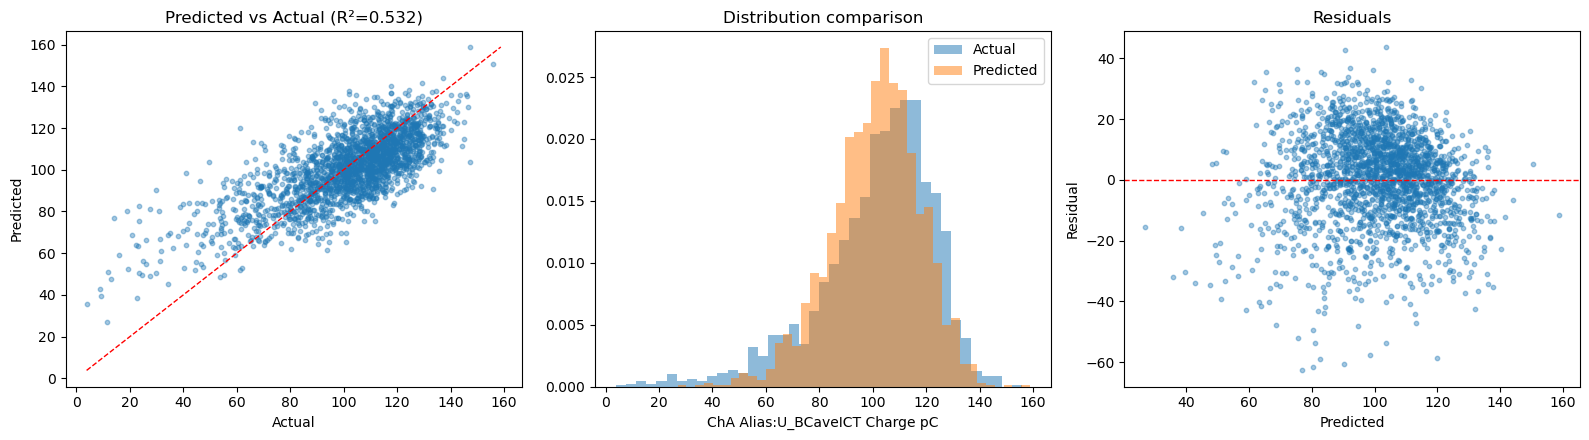

Test R²: 0.532
Residual RMS: 14.930
Signal RMS: 21.850
Residual/Mean: 14.7%


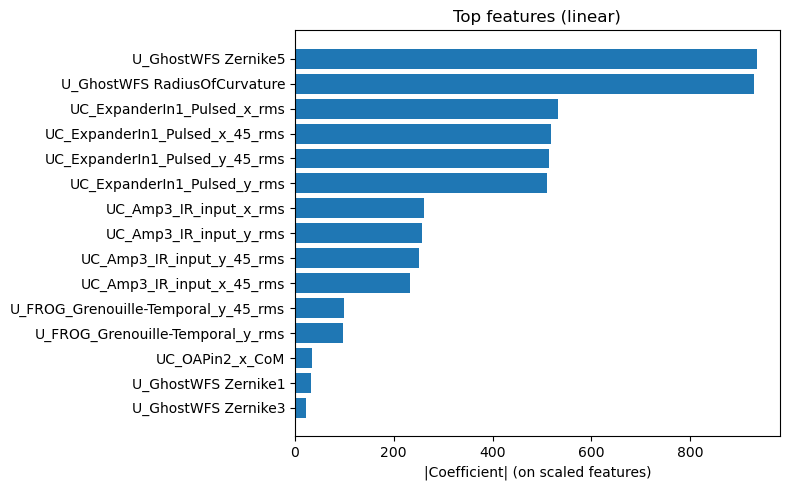

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

bp = study.best_params
top_n = bp["top_n_features"]
features = corrs.index[:top_n].tolist()

sub = df_filt[[key_column] + features].dropna()
X_ot = sub[features].values
y_ot = sub[key_column].values

model_name = bp["model"]
if model_name == "ridge":
    best_model = Ridge(alpha=bp["alpha"])
elif model_name == "lasso":
    best_model = Lasso(alpha=bp["alpha"], max_iter=5000)
elif model_name == "elasticnet":
    best_model = ElasticNet(alpha=bp["alpha"], l1_ratio=bp["l1_ratio"], max_iter=5000)
elif model_name == "rf":
    best_model = RandomForestRegressor(
        n_estimators=bp["n_estimators"],
        max_depth=bp["max_depth"],
        random_state=42,
    )
elif model_name == "pls":
    best_model = PLSRegression(n_components=bp["n_components"])
else:
    best_model = LinearRegression()

pipe = Pipeline([("scaler", StandardScaler()), ("model", best_model)])

X_train, X_test, y_train, y_test = train_test_split(
    X_ot, y_ot, test_size=0.3, random_state=42
)
pipe.fit(X_train, y_train)
y_pred_ot = pipe.predict(X_test).ravel()

r2_test = pipe.score(X_test, y_test)
residuals = y_test - y_pred_ot

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(y_test, y_pred_ot, alpha=0.4, s=10)
lims = [min(y_test.min(), y_pred_ot.min()), max(y_test.max(), y_pred_ot.max())]
axes[0].plot(lims, lims, "r--", lw=1)
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")
axes[0].set_title(f"Predicted vs Actual (R²={r2_test:.3f})")

axes[1].hist(y_test, bins=40, alpha=0.5, label="Actual", density=True)
axes[1].hist(y_pred_ot, bins=40, alpha=0.5, label="Predicted", density=True)
axes[1].set_xlabel(key_column.split(".")[-1])
axes[1].set_title("Distribution comparison")
axes[1].legend()

axes[2].scatter(y_pred_ot, residuals, alpha=0.4, s=10)
axes[2].axhline(0, color="r", linestyle="--", lw=1)
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Residual")
axes[2].set_title("Residuals")

plt.tight_layout()
plt.show()

print(f"Test R²: {r2_test:.3f}")
print(f"Residual RMS: {np.std(residuals):.3f}")
print(f"Signal RMS: {np.std(y_test):.3f}")
print(f"Residual/Mean: {np.std(residuals) / np.mean(y_test):.1%}")

fitted_model = pipe.named_steps["model"]
if hasattr(fitted_model, "feature_importances_"):
    imp = fitted_model.feature_importances_
    idx = np.argsort(imp)[-15:]
    plt.figure(figsize=(8, 5))
    plt.barh([features[i] for i in idx], imp[idx])
    plt.xlabel("Feature Importance")
    plt.title(f"Top features ({model_name})")
    plt.tight_layout()
    plt.show()
elif hasattr(fitted_model, "coef_"):
    coefs = np.abs(np.array(fitted_model.coef_).ravel())
    idx = np.argsort(coefs)[-15:]
    plt.figure(figsize=(8, 5))
    plt.barh([features[i] for i in idx], coefs[idx])
    plt.xlabel("|Coefficient| (on scaled features)")
    plt.title(f"Top features ({model_name})")
    plt.tight_layout()
    plt.show()

In [13]:
top_keep = study.best_params["top_n_features"]
features_best = corrs.index[:top_keep].tolist()

df_clean = df_filt.dropna(subset=[key_column] + check_columns)
sub_best = df_filt[[key_column] + features_best].dropna()

print(f"All ranked features: {len(df_clean)} rows, {len(check_columns)} features")
print(f"Optuna best subset: {len(sub_best)} rows, {top_keep} features")

All ranked features: 7167 rows, 100 features
Optuna best subset: 7167 rows, 100 features


#### Plain pipeline CV (linear regression)

**`Pipeline`** + **`cross_val_score`** with 3-fold, 5-fold, and **`ShuffleSplit`** — same checks as **`basic_usage.ipynb`**.


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

df_clean = df_filt.dropna(subset=[key_column] + check_columns)
X_cv = df_clean[check_columns].values
y_cv = df_clean[key_column].values

pipe = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])

cv3 = cross_val_score(pipe, X_cv, y_cv, cv=3, scoring="r2")
cv5 = cross_val_score(pipe, X_cv, y_cv, cv=5, scoring="r2")

print(f"3-fold CV R²: {cv3.mean():.3f} ± {cv3.std():.3f}  (per fold: {cv3})")
print(f"5-fold CV R²: {cv5.mean():.3f} ± {cv5.std():.3f}  (per fold: {cv5})")

cv = ShuffleSplit(n_splits=5, test_size=0.3, random_state=42)
scores = cross_val_score(pipe, X_cv, y_cv, cv=cv, scoring="r2")
print(f"ShuffleSplit CV R²: {scores.mean():.3f} ± {scores.std():.3f}")

3-fold CV R²: 0.405 ± 0.072  (per fold: [0.34235019 0.50618298 0.36573538])
5-fold CV R²: 0.511 ± 0.039  (per fold: [0.48898547 0.53185648 0.49502826 0.57435916 0.46360793])
ShuffleSplit CV R²: 0.544 ± 0.008


### Packaged fit / persist / reload (`RegressionTrainer`)

Earlier cells used **sklearn directly** for teaching; **`BeamPredictionDatasetBuilder`** only standardized the tabular **`X`** / **`y`** matrix.

The **`modeling.ml`** layer adds **`RegressionTrainer`** (default preprocessing pipeline + linear / ridge / elastic-net), **`TrainingMetrics`** (optional **`cv`** summary), and **`save_model_artifact`** / **`load_model_artifact`** for a directory of **`joblib` + JSON sidecars**. Run after the **modeling setup** cell that defines **`ml_ds`**.


In [16]:
import tempfile
from pathlib import Path

import pandas as pd

from geecs_data_utils.modeling.ml import (
    RegressionTrainer,
    load_model_artifact,
    save_model_artifact,
)

# Uses ml_ds from the modeling setup cell (same merged-scan table).
top_k = min(25, len(ml_ds.feature_columns))
feat_cols = ml_ds.feature_columns[:top_k]
X_demo = ml_ds.frame[feat_cols]
y_demo = ml_ds.frame[ml_ds.target_column]

trainer = RegressionTrainer(model="ridge", model_params={"alpha": 1.0})
artifact = trainer.fit(
    X_demo,
    y_demo,
    cv=5,
    target_name="ict_charge_pc",
    scan_info={"notebook": "basic_usage_refactor"},
)

print(f"In-sample R²: {artifact.metrics.r2:.4f}")
if artifact.metrics.cv_r2_mean is not None:
    print(
        "5-fold CV R²:",
        f"{artifact.metrics.cv_r2_mean:.4f} ± {artifact.metrics.cv_r2_std:.4f}",
    )

tmpdir = Path(tempfile.mkdtemp(prefix="geecs_ml_demo_"))
artifact_dir = tmpdir / "ridge_charge_demo"
save_model_artifact(artifact, artifact_dir)
print("Saved artifact dir:", artifact_dir)

loaded = load_model_artifact(artifact_dir)
preview = X_demo.iloc[:3]
pred = loaded.predict(preview)
actual = y_demo.iloc[:3].to_numpy()
compare = pd.DataFrame({"actual": actual, "predicted": pred, "residual": pred - actual})
print(compare.round(4).to_string(index=False))

In-sample R²: 0.3624
5-fold CV R²: 0.2930 ± 0.0757
Saved artifact dir: /var/folders/q7/_y69ny8d0tnffxy8c5y6xmvr0000gn/T/geecs_ml_demo_w4jzdcgq/ridge_charge_demo
  actual  predicted  residual
 91.2573   116.5987   25.3413
116.8515   108.9565   -7.8950
113.5341   118.7132    5.1791
